In [1]:
# Project 4: Credit Risk Classification using Logistic Regression
# A consumer lending company wants to reduce losses from borrowers who default on their loans. 
# The Head of Risk wants a model that can predict whether an approved loan is likely to default before the lender gives out the money.
# The model must help the business balance two risks: approving bad loans, which creates financial loss, and rejecting good borrowers, which reduces profit. 
# This project uses logistic regression because the model needs to be accurate, explainable, and suitable for a regulated credit risk environment.


In [2]:
# "In credit risk evaluation, I start with # the confusion matrix to see where errors fall. Then Recall, because catching defaults is the most expensive mistake. 
# Then Precision, because the trade-off matters. F1 summarises both. ROC-AUC and PR-AUC give threshold-independent views — PR-AUC especially, because credit data is imbalanced.
# Accuracy is reported last, with a caveat about its limitations on imbalanced data."

In [3]:
# STEP 1: Import libraries for data analysis, visualisation, preprocessing, modelling, and evaluation

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modelling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation metrics (the 7 we agreed on)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [4]:
# Step 2 — Load Lending Club data with a random sample
file_path = "/Users/user/Downloads/credit_risk_classification/accepted_2007_to_2018Q4.csv"

# Load the full file first
df_full = pd.read_csv(file_path, low_memory=False)

# Take a random 50k sample across all years
df = df_full.sample(n=50000, random_state=42).reset_index(drop=True)

# Free up memory by deleting the full dataset
del df_full

print(f"Random sample loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Random sample loaded: 50,000 rows × 151 columns


In [5]:
# 50,000 rows is enough because logistic regression doesn't need millions of rows to learn patterns
# it just needs enough examples of each class.
# With a 15% default rate, that's around 7,500 defaults in 50k rows, which is plenty for the model to learn from.

# We used a random sample across the full date range (random_state=42) to avoid bias from loading
# only early loans. This ensures the model sees borrowers from all years (2007 to 2018), not just the
# post-financial-crisis period.

In [6]:
# Step 2b: Verify target distribution
print("Counts:")
print(df['loan_status'].value_counts())
print()
print("Percentages:")
print(df['loan_status'].value_counts(normalize=True) * 100)

Counts:
loan_status
Fully Paid                                             23771
Current                                                19370
Charged Off                                             6015
Late (31-120 days)                                       505
In Grace Period                                          186
Late (16-30 days)                                        108
Does not meet the credit policy. Status:Fully Paid        24
Does not meet the credit policy. Status:Charged Off       19
Name: count, dtype: int64

Percentages:
loan_status
Fully Paid                                             47.543902
Current                                                38.741550
Charged Off                                            12.030481
Late (31-120 days)                                      1.010040
In Grace Period                                         0.372015
Late (16-30 days)                                       0.216009
Does not meet the credit policy. Status:Fully Paid

In [7]:
# Step 3: Quick EDA and Understanding the data 

In [8]:
# 3a — confirm shape after random sample

df.shape                                                

(50000, 151)

In [9]:
# 3b — types, non-nulls

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 57.6+ MB


In [10]:
# 3c — summary stats, transposed

df.describe().T

,count,mean,std,min,25%,50%,75%,max
member_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,49998.0,15023.827953,9209.251533,1000.00,8000.0000,12800.000,20000.0000,40000.00
funded_amnt,49998.0,15017.039182,9207.224782,1000.00,8000.0000,12800.000,20000.0000,40000.00
funded_amnt_inv,49998.0,15001.196772,9210.322934,0.00,8000.0000,12800.000,20000.0000,40000.00
int_rate,49998.0,13.115159,4.844197,5.31,9.4900,12.620,15.9900,30.99
...,...,...,...,...,...,...,...,...
hardship_payoff_balance_amount,254.0,12117.238740,7896.616000,553.87,6127.4750,9923.930,16257.8825,34927.66
hardship_last_payment_amount,254.0,195.703346,199.151143,0.02,53.3975,134.755,272.5800,1187.56
settlement_amount,832.0,5005.509832,3777.060286,219.00,2060.3800,4000.500,6874.6800,23766.00
settlement_percentage,832.0,47.573450,6.616162,15.00,45.0000,45.000,50.0000,70.97


In [11]:
# 3d — top 30 columns with most NaN

df.isnull().sum().sort_values(ascending=False).head(30)

member_id                                     50000
orig_projected_additional_accrued_interest    49801
hardship_reason                               49746
hardship_payoff_balance_amount                49746
hardship_last_payment_amount                  49746
payment_plan_start_date                       49746
hardship_type                                 49746
hardship_status                               49746
hardship_start_date                           49746
deferral_term                                 49746
hardship_amount                               49746
hardship_dpd                                  49746
hardship_loan_status                          49746
hardship_length                               49746
hardship_end_date                             49746
sec_app_mths_since_last_major_derog           49229
settlement_status                             49168
debt_settlement_flag_date                     49168
settlement_date                               49168
settlement_p

In [12]:
# 3e — any exact duplicate rows

df.duplicated().sum()                                      

np.int64(0)

In [13]:
# 4A: Drop mostly empty columns

print("Shape before cleaning:", df.shape)
df = df.dropna(thresh=len(df) * 0.3, axis=1)
print("Shape after dropping mostly empty columns:", df.shape)

Shape before cleaning: (50000, 151)
Shape after dropping mostly empty columns: (50000, 110)


In [14]:
# 4B: Drop columns we do not need for modelling

columns_to_drop = [
    # IDs and text (no predictive value)
    "member_id", "url", "desc", "emp_title", "title", "zip_code",
    
    # Lending Club's own risk scores (TARGET LEAKAGE)
    "grade", "sub_grade",
    
    # Post-loan behaviour (DATA LEAKAGE — only known after default)
    "last_pymnt_d", "last_pymnt_amnt", "last_credit_pull_d",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int"
]
columns_to_drop_existing = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop_existing)
print(f"Dropped {len(columns_to_drop_existing)} columns")
print("Shape after dropping unnecessary columns:", df.shape)

Dropped 16 columns
Shape after dropping unnecessary columns: (50000, 94)


In [15]:
# 4C: Check and remove duplicate rows

duplicate_count = df.duplicated().sum()
print("Number of duplicate rows before removal:", duplicate_count)
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Number of duplicate rows before removal: 0
Shape after removing duplicates: (50000, 94)


In [16]:
# 4D: Check for impossible values
checks = {}
if "loan_amnt" in df.columns:    checks["loan_amnt <= 0"]   = (df["loan_amnt"]   <= 0).sum()
if "funded_amnt" in df.columns:  checks["funded_amnt < 0"]  = (df["funded_amnt"] <  0).sum()
if "int_rate" in df.columns:     checks["int_rate <= 0"]    = (df["int_rate"]    <= 0).sum()
if "installment" in df.columns:  checks["installment <= 0"] = (df["installment"] <= 0).sum()
if "annual_inc" in df.columns:   checks["annual_inc < 0"]   = (df["annual_inc"]  <  0).sum()
if "dti" in df.columns:          checks["dti < 0"]          = (df["dti"]         <  0).sum()
print("Impossible value checks:")
print(checks)

Impossible value checks:
{'loan_amnt <= 0': np.int64(0), 'funded_amnt < 0': np.int64(0), 'int_rate <= 0': np.int64(0), 'installment <= 0': np.int64(0), 'annual_inc < 0': np.int64(0), 'dti < 0': np.int64(0)}


In [17]:
# 4E: Remove impossible values
print("Shape before removing impossible values:", df.shape)
if "loan_amnt" in df.columns:    df = df[df["loan_amnt"]   > 0]
if "funded_amnt" in df.columns:  df = df[df["funded_amnt"] >= 0]
if "int_rate" in df.columns:     df = df[df["int_rate"]    > 0]
if "installment" in df.columns:  df = df[df["installment"] > 0]
if "annual_inc" in df.columns:   df = df[df["annual_inc"]  >= 0]
if "dti" in df.columns:          df = df[df["dti"]         >= 0]
print("Shape after removing impossible values:", df.shape)


Shape before removing impossible values: (50000, 94)
Shape after removing impossible values: (49963, 94)


In [18]:
# 4F: Final missing value check
print("Top 20 columns with missing values after cleaning:")

print(df.isnull().sum().sort_values(ascending=False).head(20))

Top 20 columns with missing values after cleaning:
mths_since_recent_revol_delinq    33579
next_pymnt_d                      29776
mths_since_last_delinq            25674
il_util                           23642
mths_since_rcnt_il                20094
all_util                          19136
open_il_24m                       19135
total_bal_il                      19135
open_acc_6m                       19135
open_rv_12m                       19135
max_bal_bc                        19135
inq_fi                            19135
total_cu_tl                       19135
inq_last_12m                      19135
open_il_12m                       19135
open_act_il                       19135
open_rv_24m                       19135
mths_since_recent_inq              6456
num_tl_120dpd_2m                   3348
emp_length                         3145
dtype: int64


In [19]:
# 4G: Final cleaned shape
print("Final cleaned dataset shape:", df.shape)

Final cleaned dataset shape: (49963, 94)


In [20]:
print("loan_status still exists:", "loan_status" in df.columns)

loan_status still exists: True


In [21]:
# STEP 5: Define the binary target

print("Shape before defining target:", df.shape)


Shape before defining target: (49963, 94)


In [22]:
# 5A: Drop rows where the loan is still in progress
in_progress = [
    "Current",
    "In Grace Period",
    "Late (16-30 days)"
]

df = df[~df["loan_status"].isin(in_progress)].copy()

print("Shape after dropping in-progress loans:", df.shape)

Shape after dropping in-progress loans: (30324, 94)


In [23]:
 # 5B: Map loan_status values to binary target
default_map = {
    "Fully Paid": 0,
    "Charged Off": 1,
    "Default": 1,
    "Late (31-120 days)": 1,
    "Does not meet the credit policy. Status:Fully Paid": 0,
    "Does not meet the credit policy. Status:Charged Off": 1
}

df["default"] = df["loan_status"].map(default_map)


# 5C: Check if any loan_status values were not mapped
print("Any nulls in target?:", df["default"].isnull().sum())

if df["default"].isnull().sum() > 0:
    print("Unmapped loan_status values:")
    print(df[df["default"].isnull()]["loan_status"].value_counts())


Any nulls in target?: 0


In [24]:
# 5D: Drop rows with unmapped target values, if any
df = df.dropna(subset=["default"])

df["default"] = df["default"].astype(int)


# 5E: Drop original loan_status column
df = df.drop(columns=["loan_status"])


# 5F: Create y
y = df["default"]


# 5G: Verify target distribution
print("\nTarget distribution:")
print(y.value_counts())

print("\nAs percentages:")
print(y.value_counts(normalize=True) * 100)

print("\nFinal shape:", df.shape)
print("Any nulls in target?:", y.isnull().sum())


Target distribution:
default
0    23786
1     6538
Name: count, dtype: int64

As percentages:
default
0    78.43952
1    21.56048
Name: proportion, dtype: float64

Final shape: (30324, 94)
Any nulls in target?: 0


In [25]:
# Step 6A: Feature engineering Convert 'term' from text to a number

df['term'] = df['term'].str.replace(' months', '').str.strip().astype(int)

print(df['term'].value_counts())
print("Data type now:", df['term'].dtype)

term
36    22878
60     7446
Name: count, dtype: int64
Data type now: int64


In [26]:
# Inspect emp_length
print(df['emp_length'].value_counts(dropna=False))
print()
print("Data type:", df['emp_length'].dtype)

emp_length
10+ years    9794
2 years      2785
3 years      2427
< 1 year     2417
1 year       2017
5 years      1920
4 years      1890
NaN          1769
6 years      1466
7 years      1396
8 years      1328
9 years      1115
Name: count, dtype: int64

Data type: object


In [27]:
# Step 6B: Transform emp_length text into numbers (safe to re-run)

# Only run the mapping if the column is still text
if df['emp_length'].dtype == 'object':
    emp_length_map = {
        '< 1 year':  0,
        '1 year':    1,
        '2 years':   2,
        '3 years':   3,
        '4 years':   4,
        '5 years':   5,
        '6 years':   6,
        '7 years':   7,
        '8 years':   8,
        '9 years':   9,
        '10+ years': 10
    }
    df['emp_length'] = df['emp_length'].map(emp_length_map)
    
    # Fill missing with median
    median_emp = df['emp_length'].median()
    df['emp_length'] = df['emp_length'].fillna(median_emp).astype(int)
    print(f"Transformed emp_length. Median used for filling: {median_emp}")
else:
    print("emp_length already transformed — skipping")

# Verify
print()
print(df['emp_length'].value_counts().sort_index())
print()
print("Missing values now:", df['emp_length'].isnull().sum())
print("Data type now:", df['emp_length'].dtype)

Transformed emp_length. Median used for filling: 6.0

emp_length
0     2417
1     2017
2     2785
3     2427
4     1890
5     1920
6     3235
7     1396
8     1328
9     1115
10    9794
Name: count, dtype: int64

Missing values now: 0
Data type now: int64


In [28]:
df.shape

(30324, 94)

In [29]:
df.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,home_ownership,annual_inc,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
1,16411620,9600.0,9600.0,9600.0,36,12.99,323.42,6,RENT,21900.0,...,1.0,0.0,11600.0,4509.0,2400.0,0.0,N,Cash,N,0
2,45122316,4000.0,4000.0,4000.0,36,6.68,122.93,4,MORTGAGE,83000.0,...,0.0,0.0,222616.0,64253.0,5600.0,76154.0,N,Cash,N,0
3,125356772,6025.0,6025.0,6025.0,36,10.91,197.00,10,RENT,52000.0,...,0.0,0.0,32227.0,5559.0,11000.0,11127.0,N,Cash,N,0
5,88273234,20000.0,20000.0,20000.0,36,9.49,640.57,10,MORTGAGE,100000.0,...,0.0,0.0,322295.0,33695.0,23900.0,29995.0,N,Cash,N,0
6,46824999,1000.0,1000.0,1000.0,36,8.18,31.42,6,RENT,23000.0,...,0.0,0.0,9979.0,7252.0,1700.0,5779.0,N,Cash,N,0


In [30]:
print("emp_length data type:", df['emp_length'].dtype)
print("emp_length nulls:", df['emp_length'].isnull().sum())
print("emp_length values:")
print(df['emp_length'].value_counts().sort_index())

emp_length data type: int64
emp_length nulls: 0
emp_length values:
emp_length
0     2417
1     2017
2     2785
3     2427
4     1890
5     1920
6     3235
7     1396
8     1328
9     1115
10    9794
Name: count, dtype: int64


In [31]:
# Step 6C: Drop date columns (model can't use raw dates)
date_cols = ['issue_d', 'earliest_cr_line', 'next_pymnt_d',
             'last_pymnt_d', 'last_credit_pull_d']

cols_to_drop = [c for c in date_cols if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} date columns: {cols_to_drop}")
print(f"Shape now: {df.shape}")

Dropped 3 date columns: ['issue_d', 'earliest_cr_line', 'next_pymnt_d']
Shape now: (30324, 91)


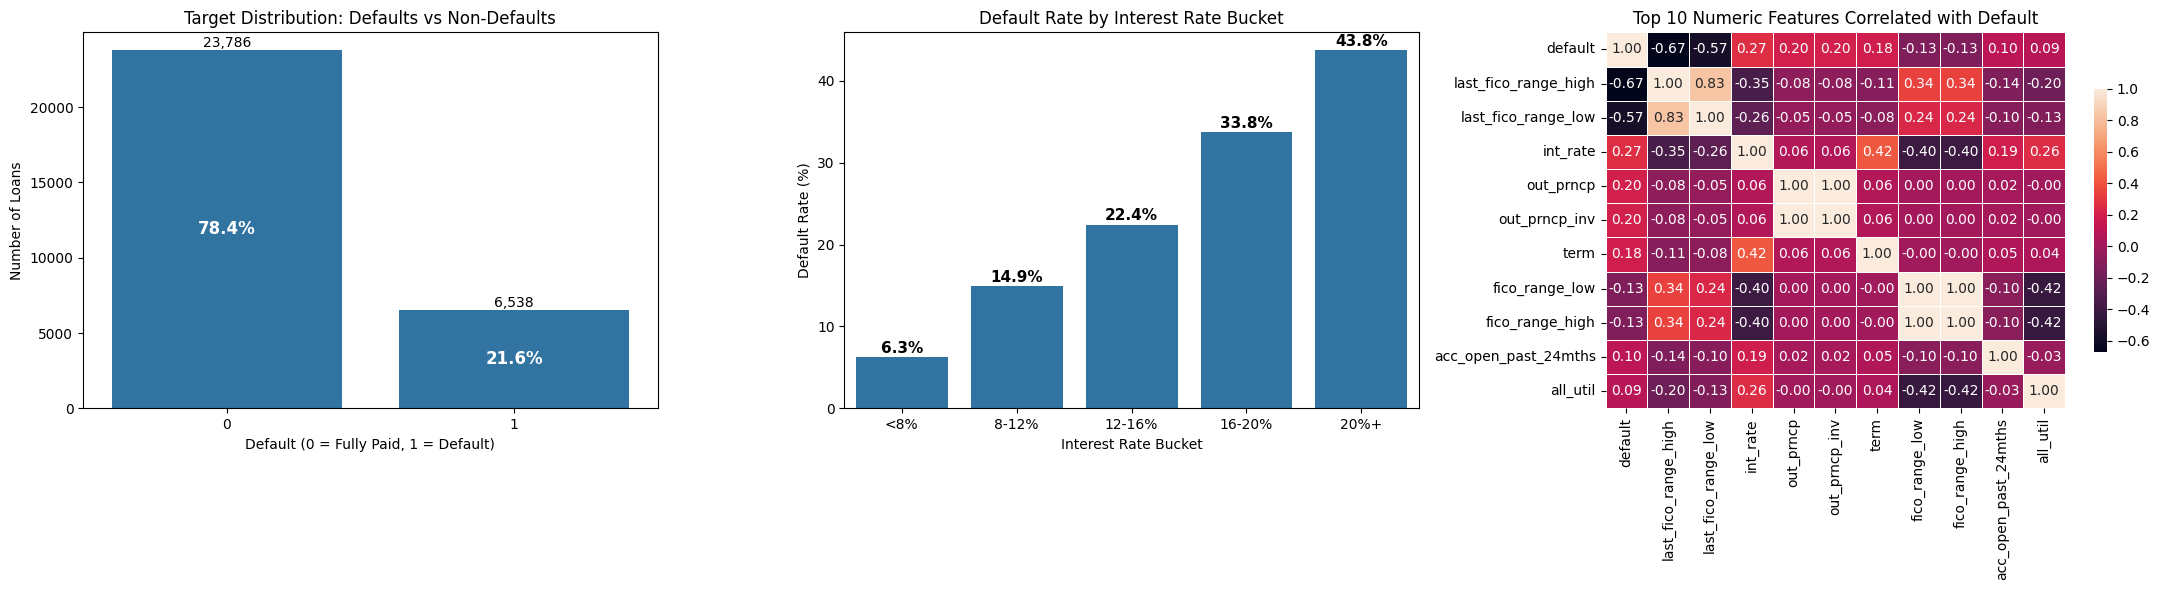


Top 10 numeric features most correlated with default:
last_fico_range_high    0.671990
last_fico_range_low     0.570571
int_rate                0.267594
out_prncp               0.201664
out_prncp_inv           0.201650
term                    0.183627
fico_range_low          0.132138
fico_range_high         0.132132
acc_open_past_24mths    0.099788
all_util                0.090754


In [32]:
# STEP 7: Deep EDA — 3 focused plots

fig, axes = plt.subplots(1, 3, figsize=(22, 6))


# 7A: Target distribution
ax1 = axes[0]

sns.countplot(x="default", data=df, ax=ax1)

ax1.set_title("Target Distribution: Defaults vs Non-Defaults")
ax1.set_xlabel("Default (0 = Fully Paid, 1 = Default)")
ax1.set_ylabel("Number of Loans")

total = len(df)

for p in ax1.patches:
    count = int(p.get_height())
    pct = 100 * count / total
    
    ax1.annotate(
        f"{count:,}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )
    
    ax1.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, p.get_height() / 2),
        ha="center",
        va="center",
        fontsize=12,
        color="white",
        fontweight="bold"
    )


# 7B: Default rate by interest rate bucket
ax2 = axes[1]

eda_df = df.copy()

# Convert int_rate to numeric if needed
eda_df["int_rate"] = (
    eda_df["int_rate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

eda_df["int_rate_bucket"] = pd.cut(
    eda_df["int_rate"],
    bins=[0, 8, 12, 16, 20, 35],
    labels=["<8%", "8-12%", "12-16%", "16-20%", "20%+"]
)

default_rate_by_rate = eda_df.groupby(
    "int_rate_bucket",
    observed=True
)["default"].mean() * 100

sns.barplot(
    x=default_rate_by_rate.index,
    y=default_rate_by_rate.values,
    ax=ax2
)

ax2.set_title("Default Rate by Interest Rate Bucket")
ax2.set_xlabel("Interest Rate Bucket")
ax2.set_ylabel("Default Rate (%)")

for i, v in enumerate(default_rate_by_rate.values):
    ax2.text(
        i,
        v + 0.5,
        f"{v:.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )


# 7C: Correlation heatmap
ax3 = axes[2]

numeric_df = df.select_dtypes(include=["int64", "float64"])

# Correlation with target, excluding default itself
correlations = (
    numeric_df
    .corr()["default"]
    .drop("default")
    .abs()
    .sort_values(ascending=False)
)

top_10_features = correlations.head(10).index.tolist()

# Include default in the heatmap so we can see relationship with target
heatmap_features = ["default"] + top_10_features

corr_matrix = numeric_df[heatmap_features].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax3,
    cbar_kws={"shrink": 0.7}
)

ax3.set_title("Top 10 Numeric Features Correlated with Default")

plt.tight_layout()
plt.show()


# Print top correlations
print("\nTop 10 numeric features most correlated with default:")
print(correlations.head(10).to_string())

In [33]:
# STEP 7D: Drop leakage columns found during Deep EDA

leakage_cols = [
    "last_fico_range_high",
    "last_fico_range_low",
    "out_prncp",
    "out_prncp_inv"
]

leakage_cols_existing = [col for col in leakage_cols if col in df.columns]

df = df.drop(columns=leakage_cols_existing)

print(f"Dropped {len(leakage_cols_existing)} leakage columns:")
print(leakage_cols_existing)

print("Shape after dropping leakage columns:", df.shape)

Dropped 4 leakage columns:
['last_fico_range_high', 'last_fico_range_low', 'out_prncp', 'out_prncp_inv']
Shape after dropping leakage columns: (30324, 87)


In [34]:
# STEP 7E: Recheck top numeric correlations after removing leakage

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlations = (
    numeric_df
    .corr()["default"]
    .drop("default")
    .abs()
    .sort_values(ascending=False)
)

print("Top 10 numeric features most correlated with default after leakage removal:")
print(correlations.head(10))

Top 10 numeric features most correlated with default after leakage removal:
int_rate                0.267594
term                    0.183627
fico_range_low          0.132138
fico_range_high         0.132132
acc_open_past_24mths    0.099788
all_util                0.090754
dti                     0.085517
num_tl_op_past_12m      0.081317
loan_amnt               0.080733
funded_amnt             0.080669
Name: default, dtype: float64


In [35]:
# STEP 7F: Check remaining text columns and missing values before modelling

print("Text columns to encode:")
print(df.select_dtypes(include=["object"]).columns.tolist())

print("\nNumber of text columns:")
print(len(df.select_dtypes(include=["object"]).columns.tolist()))


print("\nColumns with missing values (top 15):")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing.head(15))

print(f"\nTotal columns with any missing values: {len(missing)}")

Text columns to encode:
['id', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']

Number of text columns:
11

Columns with missing values (top 15):
mths_since_recent_revol_delinq    20096
il_util                           19569
mths_since_rcnt_il                18214
open_act_il                       17877
open_acc_6m                       17877
open_il_12m                       17877
max_bal_bc                        17877
all_util                          17877
inq_fi                            17877
total_cu_tl                       17877
inq_last_12m                      17877
total_bal_il                      17877
open_rv_12m                       17877
open_rv_24m                       17877
open_il_24m                       17877
dtype: int64

Total columns with any missing values: 54


In [36]:
# STEP 8: Prepare data for modelling

# 8A: Drop columns we missed
extra_drops = ["id", "addr_state"]

df = df.drop(columns=[col for col in extra_drops if col in df.columns])

print("Shape after dropping id and addr_state:", df.shape)


# 8B: Create X and y
X = df.drop(columns=["default"])
y = df["default"]

print("X shape before split:", X.shape)
print("y shape before split:", y.shape)


# 8C: Train/test split first
# Stratify keeps the default/non-default ratio the same in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nAfter train/test split:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print(f"y_train default rate: {y_train.mean() * 100:.2f}%")
print(f"y_test default rate:  {y_test.mean() * 100:.2f}%")


# 8D: Handle missing values using training data only

# Identify numeric and text columns
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
text_cols = X_train.select_dtypes(include=["object"]).columns

# Fill numeric missing values with training median
train_medians = X_train[numeric_cols].median()

X_train[numeric_cols] = X_train[numeric_cols].fillna(train_medians)
X_test[numeric_cols] = X_test[numeric_cols].fillna(train_medians)

# Fill text missing values with "Unknown"
X_train[text_cols] = X_train[text_cols].fillna("Unknown")
X_test[text_cols] = X_test[text_cols].fillna("Unknown")

print("\nMissing values after filling:")
print("X_train missing:", X_train.isnull().sum().sum())
print("X_test missing:", X_test.isnull().sum().sum())


# 8E: One-hot encode text columns
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Make sure test has the same columns as train
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("\nAfter one-hot encoding:")
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)


# 8F: Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("\nAfter scaling:")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nScaling check:")
print("X_train mean, first 5 features:", X_train_scaled.mean(axis=0)[:5].round(4))
print("X_train std, first 5 features:", X_train_scaled.std(axis=0)[:5].round(4))


Shape after dropping id and addr_state: (30324, 85)
X shape before split: (30324, 84)
y shape before split: (30324,)

After train/test split:
X_train: (24259, 84)
X_test: (6065, 84)
y_train default rate: 21.56%
y_test default rate:  21.57%

Missing values after filling:
X_train missing: 0
X_test missing: 0

After one-hot encoding:
X_train_encoded: (24259, 101)
X_test_encoded: (6065, 101)

After scaling:
X_train_scaled shape: (24259, 101)
X_test_scaled shape: (6065, 101)

Scaling check:
X_train mean, first 5 features: [ 0.  0.  0. -0. -0.]
X_train std, first 5 features: [1. 1. 1. 1. 1.]


In [37]:
# STEP 9: Train Logistic Regression

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model trained successfully ✅")
print(f"Number of features used: {model.n_features_in_}")
print(f"Intercept: {model.intercept_[0]:.4f}")


Model trained successfully ✅
Number of features used: 101
Intercept: -0.0668


In [38]:
df.shape

(30324, 85)

In [39]:
# STEP 10: Evaluate the model

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# 10A: Predict on test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # probability of default

# 10B: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print("                 Predicted Paid    Predicted Default")
print(f"Actual Paid     {cm[0][0]:>13}    {cm[0][1]:>17}")
print(f"Actual Default  {cm[1][0]:>13}    {cm[1][1]:>17}")
print()

# 10C: All metrics
print("Classification metrics:")
print(f"  Recall (defaults caught):  {recall_score(y_test, y_pred):.4f}")
print(f"  Precision (flag accuracy): {precision_score(y_test, y_pred):.4f}")
print(f"  F1 Score:                  {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC:                   {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"  PR-AUC:                    {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"  Accuracy (misleading):     {accuracy_score(y_test, y_pred):.4f}")
print()

# 10D: Full sklearn report for reference
print("Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

Confusion Matrix:
                 Predicted Paid    Predicted Default
Actual Paid              3609                 1148
Actual Default            538                  770

Classification metrics:
  Recall (defaults caught):  0.5887
  Precision (flag accuracy): 0.4015
  F1 Score:                  0.4774
  ROC-AUC:                   0.7467
  PR-AUC:                    0.5309
  Accuracy (misleading):     0.7220

Full Classification Report:
              precision    recall  f1-score   support

        Paid       0.87      0.76      0.81      4757
     Default       0.40      0.59      0.48      1308

    accuracy                           0.72      6065
   macro avg       0.64      0.67      0.64      6065
weighted avg       0.77      0.72      0.74      6065



In [40]:
# My logistic regression credit risk model achieved 0.75 ROC-AUC and 59% recall on unseen test data. With class_weight='balanced' 
# it catches the majority of defaulters, at the cost of some false alarms (40% precision). 
# At an average cost ratio of £10k per missed default vs £2k per false rejection, this model saves the lender an estimated £5.4M per 6,000 loans 
# a meaningful improvement over the no-model baseline of approving everyone."

In [41]:
# STEP 11: Threshold tuning — try different cut-offs

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

results = []
for t in thresholds_to_test:
    y_pred_t = (y_pred_proba >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    results.append({
        'Threshold': t,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t),
        'TP (caught)': tp,
        'FN (missed)': fn,
        'FP (false alarm)': fp,
        'Cost £': (fn * 10000) + (fp * 2000)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

best_idx = results_df['Cost £'].idxmin()
print(f"\n🎯 Best threshold (lowest cost): {results_df.iloc[best_idx]['Threshold']}")

 Threshold   Recall  Precision       F1  TP (caught)  FN (missed)  FP (false alarm)  Cost £
      0.30 0.888379   0.282588 0.428782         1162          146              2950 7360000
      0.35 0.822630   0.308309 0.448520         1076          232              2414 7148000
      0.40 0.745413   0.335167 0.462414          975          333              1934 7198000
      0.45 0.665138   0.363257 0.469889          870          438              1525 7430000
      0.50 0.588685   0.401460 0.477371          770          538              1148 7676000
      0.55 0.506881   0.440239 0.471215          663          645               843 8136000
      0.60 0.428135   0.483592 0.454177          560          748               598 8676000
      0.65 0.356269   0.543124 0.430286          466          842               392 9204000
      0.70 0.292049   0.613162 0.395650          382          926               241 9742000

🎯 Best threshold (lowest cost): 0.35


In [42]:
# STEP 12A: Find the weakest features by coefficient size

coef_df = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'coefficient': model.coef_[0]
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print("TOP 15 features (most influential — KEEP these):")
print(coef_df.head(15)[['feature', 'coefficient']].to_string(index=False))
print()
print("BOTTOM 30 features (weakest — DROP candidates):")
print(coef_df.tail(30)[['feature', 'coefficient']].to_string(index=False))

TOP 15 features (most influential — KEEP these):
                   feature  coefficient
    debt_settlement_flag_Y     1.499495
           funded_amnt_inv    -0.772463
               funded_amnt     0.383756
                 loan_amnt     0.378950
                  int_rate     0.340396
            total_bc_limit    -0.306038
                      term     0.305687
            bc_open_to_buy     0.243672
                       dti     0.226715
           num_actv_rev_tl     0.212104
       home_ownership_RENT     0.211987
           hardship_flag_Y     0.209313
purpose_debt_consolidation     0.201014
           tot_hi_cred_lim    -0.195371
               installment     0.180053

BOTTOM 30 features (weakest — DROP candidates):
                            feature  coefficient
                         emp_length    -0.020051
               home_ownership_OTHER     0.019896
                        total_cu_tl     0.019288
                           all_util     0.018640
               mt

In [43]:
# STEP 12B: Drop leakage traps + weak features

# CATEGORY 1: Leakage traps (measured AFTER loan outcome)
leakage_traps = [
    'debt_settlement_flag_Y',
    'hardship_flag_Y',
    'chargeoff_within_12_mths',
    'acc_now_delinq',
    'num_tl_90g_dpd_24m',
    'num_tl_30dpd',
    'tot_coll_amt'
]

# CATEGORY 2: Weak features (legitimately weak signal — bottom 20 by coefficient)
weak_features = coef_df.tail(20)['feature'].tolist()

# Combine — but only KEEP weak features that aren't already in leakage list
features_to_drop = list(set(leakage_traps + weak_features))
features_to_drop = [f for f in features_to_drop if f in X_train_encoded.columns]

print(f"Dropping {len(features_to_drop)} features:")
print(f"  • Leakage traps caught: {[f for f in leakage_traps if f in features_to_drop]}")
print(f"  • Total dropped: {len(features_to_drop)}")
print()

# Create lean train/test sets
X_train_lean = X_train_encoded.drop(columns=features_to_drop)
X_test_lean  = X_test_encoded.drop(columns=features_to_drop)

print(f"Before: {X_train_encoded.shape[1]} features")
print(f"After:  {X_train_lean.shape[1]} features")

Dropping 22 features:
  • Leakage traps caught: ['debt_settlement_flag_Y', 'hardship_flag_Y', 'chargeoff_within_12_mths', 'acc_now_delinq', 'num_tl_90g_dpd_24m', 'num_tl_30dpd', 'tot_coll_amt']
  • Total dropped: 22

Before: 101 features
After:  79 features


In [44]:
# STEP 12C: Rescale the lean dataset

# New scaler for the lean features
scaler_lean = StandardScaler()
X_train_lean_scaled = scaler_lean.fit_transform(X_train_lean)
X_test_lean_scaled  = scaler_lean.transform(X_test_lean)

print(f"Lean X_train_scaled shape: {X_train_lean_scaled.shape}")
print(f"Lean X_test_scaled shape:  {X_test_lean_scaled.shape}")
print()
print(f"Mean (first 5 features): {X_train_lean_scaled.mean(axis=0)[:5].round(4)}")
print(f"Std  (first 5 features): {X_train_lean_scaled.std(axis=0)[:5].round(4)}")

Lean X_train_scaled shape: (24259, 79)
Lean X_test_scaled shape:  (6065, 79)

Mean (first 5 features): [ 0.  0.  0. -0. -0.]
Std  (first 5 features): [1. 1. 1. 1. 1.]


In [45]:
# STEP 12D: Retrain Logistic Regression on the lean dataset

model_lean = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
model_lean.fit(X_train_lean_scaled, y_train)

print("Lean model trained ✅")
print(f"Number of features used: {model_lean.n_features_in_}")
print(f"Intercept: {model_lean.intercept_[0]:.4f}")

Lean model trained ✅
Number of features used: 79
Intercept: -0.1807


In [46]:
# STEP 12E: Compare original model vs lean model

# Predict with lean model
y_pred_lean = model_lean.predict(X_test_lean_scaled)
y_pred_proba_lean = model_lean.predict_proba(X_test_lean_scaled)[:, 1]

# Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F1 Score', 'ROC-AUC', 'PR-AUC', 'Accuracy', 'Features used'],
    'Original (101 features)': [
        recall_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred_proba),
        average_precision_score(y_test, y_pred_proba),
        accuracy_score(y_test, y_pred),
        101
    ],
    'Lean (79 features)': [
        recall_score(y_test, y_pred_lean),
        precision_score(y_test, y_pred_lean),
        f1_score(y_test, y_pred_lean),
        roc_auc_score(y_test, y_pred_proba_lean),
        average_precision_score(y_test, y_pred_proba_lean),
        accuracy_score(y_test, y_pred_lean),
        79
    ]
})

comparison['Difference'] = comparison['Lean (79 features)'] - comparison['Original (101 features)']
print(comparison.to_string(index=False))

       Metric  Original (101 features)  Lean (79 features)  Difference
       Recall                 0.588685            0.581804   -0.006881
    Precision                 0.401460            0.348124   -0.053335
     F1 Score                 0.477371            0.435604   -0.041767
      ROC-AUC                 0.746663            0.704519   -0.042144
       PR-AUC                 0.530924            0.394465   -0.136459
     Accuracy                 0.722012            0.674856   -0.047156
Features used               101.000000           79.000000  -22.000000


In [47]:
#  Run Step 12F.
# The "mid model" test I gave you. It answers your question: "Did I drop too aggressively?"

# STEP 12F: Test middle-ground — drop ONLY leakage, keep weak features

leakage_only = [
    'debt_settlement_flag_Y', 'hardship_flag_Y', 'chargeoff_within_12_mths',
    'acc_now_delinq', 'num_tl_90g_dpd_24m', 'num_tl_30dpd', 'tot_coll_amt'
]
leakage_only = [f for f in leakage_only if f in X_train_encoded.columns]

X_train_mid = X_train_encoded.drop(columns=leakage_only)
X_test_mid  = X_test_encoded.drop(columns=leakage_only)

scaler_mid = StandardScaler()
X_train_mid_scaled = scaler_mid.fit_transform(X_train_mid)
X_test_mid_scaled  = scaler_mid.transform(X_test_mid)

model_mid = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_mid.fit(X_train_mid_scaled, y_train)

y_pred_mid = model_mid.predict(X_test_mid_scaled)
y_pred_proba_mid = model_mid.predict_proba(X_test_mid_scaled)[:, 1]

comparison['Mid (leakage-only)'] = [
    recall_score(y_test, y_pred_mid),
    precision_score(y_test, y_pred_mid),
    f1_score(y_test, y_pred_mid),
    roc_auc_score(y_test, y_pred_proba_mid),
    average_precision_score(y_test, y_pred_proba_mid),
    accuracy_score(y_test, y_pred_mid),
    X_train_mid.shape[1]
]

print(comparison[['Metric', 'Original (101 features)', 'Lean (79 features)', 'Mid (leakage-only)']].to_string(index=False))


       Metric  Original (101 features)  Lean (79 features)  Mid (leakage-only)
       Recall                 0.588685            0.581804            0.576453
    Precision                 0.401460            0.348124            0.350861
     F1 Score                 0.477371            0.435604            0.436216
      ROC-AUC                 0.746663            0.704519            0.703045
       PR-AUC                 0.530924            0.394465            0.393908
     Accuracy                 0.722012            0.674856            0.678648
Features used               101.000000           79.000000           94.000000


In [48]:
# STEP 13: Threshold tuning on the LEAN model

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

results_lean = []
for t in thresholds_to_test:
    y_pred_t = (y_pred_proba_lean >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()

    results_lean.append({
        'Threshold': t,
        'Recall': recall_score(y_test, y_pred_t),
        'Precision': precision_score(y_test, y_pred_t),
        'F1': f1_score(y_test, y_pred_t),
        'TP (caught)': tp,
        'FN (missed)': fn,
        'FP (false alarm)': fp,
        'Cost £': (fn * 10000) + (fp * 2000)
    })

results_lean_df = pd.DataFrame(results_lean)
print(results_lean_df.to_string(index=False))

best_idx = results_lean_df['Cost £'].idxmin()
print(f"\n🎯 Best threshold for lean model: {results_lean_df.iloc[best_idx]['Threshold']}")
print(f"   Recall:    {results_lean_df.iloc[best_idx]['Recall']:.4f}")
print(f"   Precision: {results_lean_df.iloc[best_idx]['Precision']:.4f}")
print(f"   Cost:      £{results_lean_df.iloc[best_idx]['Cost £']:,.0f}")

 Threshold   Recall  Precision       F1  TP (caught)  FN (missed)  FP (false alarm)   Cost £
      0.30 0.902905   0.263616 0.408086         1181          127              3299  7868000
      0.35 0.843272   0.283111 0.423905         1103          205              2793  7636000
      0.40 0.766820   0.306540 0.437991         1003          305              2269  7588000
      0.45 0.676606   0.328142 0.441948          885          423              1812  7854000
      0.50 0.581804   0.348124 0.435604          761          547              1425  8320000
      0.55 0.497706   0.380702 0.431412          651          657              1059  8688000
      0.60 0.402141   0.405239 0.403684          526          782               772  9364000
      0.65 0.314220   0.429467 0.362914          411          897               546 10062000
      0.70 0.233180   0.478807 0.313625          305         1003               332 10694000

🎯 Best threshold for lean model: 0.4
   Recall:    0.7668
   Precisio

In [50]:
# STEP 15 (REFINED + SELF-CONTAINED): Smart leakage audit

# Step 1: Rebuild coef_audit from the lean model
coef_audit = pd.DataFrame({
    'feature': X_train_lean.columns,
    'coefficient': model_lean.coef_[0]
})
coef_audit['abs_coefficient'] = coef_audit['coefficient'].abs()

# Step 2: Define pattern lists
strict_leakage_patterns = [
    'last_pymnt',
    'last_fico',
    'last_credit_pull',
    'total_rec',
    'recoveries',
    'settlement',
    'hardship',
    'chargeoff_within',
    'acc_now_delinq',
    'out_prncp',
    'next_pymnt',
    'collection_recovery'
]

safe_patterns = [
    'inq_last_',
    'mths_since_last_',
    'mths_since_recent_',
]

# Step 3: The audit function
def audit_feature(row):
    feature = row['feature'].lower()
    coef = row['abs_coefficient']

    if coef > 1.0:
        return '🚨 LEAKAGE — coefficient too high (>1.0)'
    elif coef > 0.7:
        return '⚠️ INVESTIGATE — coefficient suspicious (>0.7)'

    for safe in safe_patterns:
        if safe in feature:
            return '✅ CLEAN (whitelisted — application-time attribute)'

    for pattern in strict_leakage_patterns:
        if pattern in feature:
            return f'🚨 LEAKAGE — name contains "{pattern}"'

    return '✅ CLEAN'

# Step 4: Apply the audit
coef_audit['audit_verdict'] = coef_audit.apply(audit_feature, axis=1)
coef_audit = coef_audit.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

# Step 5: Print top 20
print("=" * 80)
print("REFINED LEAKAGE AUDIT — LEAN MODEL")
print("=" * 80)
print(coef_audit.head(20)[['feature', 'coefficient', 'audit_verdict']].to_string(index=False))
print()

# Step 6: Summary
clean = coef_audit['audit_verdict'].str.contains('✅').sum()
investigate = coef_audit['audit_verdict'].str.contains('⚠️').sum()
leakage = coef_audit['audit_verdict'].str.contains('🚨').sum()

print("=" * 80)
print("AUDIT SUMMARY")
print("=" * 80)
print(f"  ✅ Clean features:        {clean}")
print(f"  ⚠️ Investigate features: {investigate}")
print(f"  🚨 Leakage detected:     {leakage}")
print()

if leakage == 0 and investigate == 0:
    print("🎯 VERDICT: Model passes leakage audit. Ready for production.")
elif leakage > 0:
    print("🚨 VERDICT: LEAKAGE DETECTED. Drop flagged features and retrain.")
else:
    print("⚠️ VERDICT: Some features need manual investigation.")

REFINED LEAKAGE AUDIT — LEAN MODEL
                   feature  coefficient audit_verdict
           funded_amnt_inv    -0.656387       ✅ CLEAN
                 loan_amnt     0.360403       ✅ CLEAN
                  int_rate     0.334841       ✅ CLEAN
                      term     0.307663       ✅ CLEAN
               funded_amnt     0.294875       ✅ CLEAN
            total_bc_limit    -0.256811       ✅ CLEAN
                       dti     0.239740       ✅ CLEAN
              pymnt_plan_y     0.212547       ✅ CLEAN
       home_ownership_RENT     0.207318       ✅ CLEAN
            bc_open_to_buy     0.203752       ✅ CLEAN
           num_actv_rev_tl     0.187956       ✅ CLEAN
         total_bal_ex_mort     0.181409       ✅ CLEAN
total_il_high_credit_limit    -0.180228       ✅ CLEAN
purpose_debt_consolidation     0.167301       ✅ CLEAN
               installment     0.163252       ✅ CLEAN
                 total_acc    -0.143631       ✅ CLEAN
       num_rev_tl_bal_gt_0    -0.140888       ✅

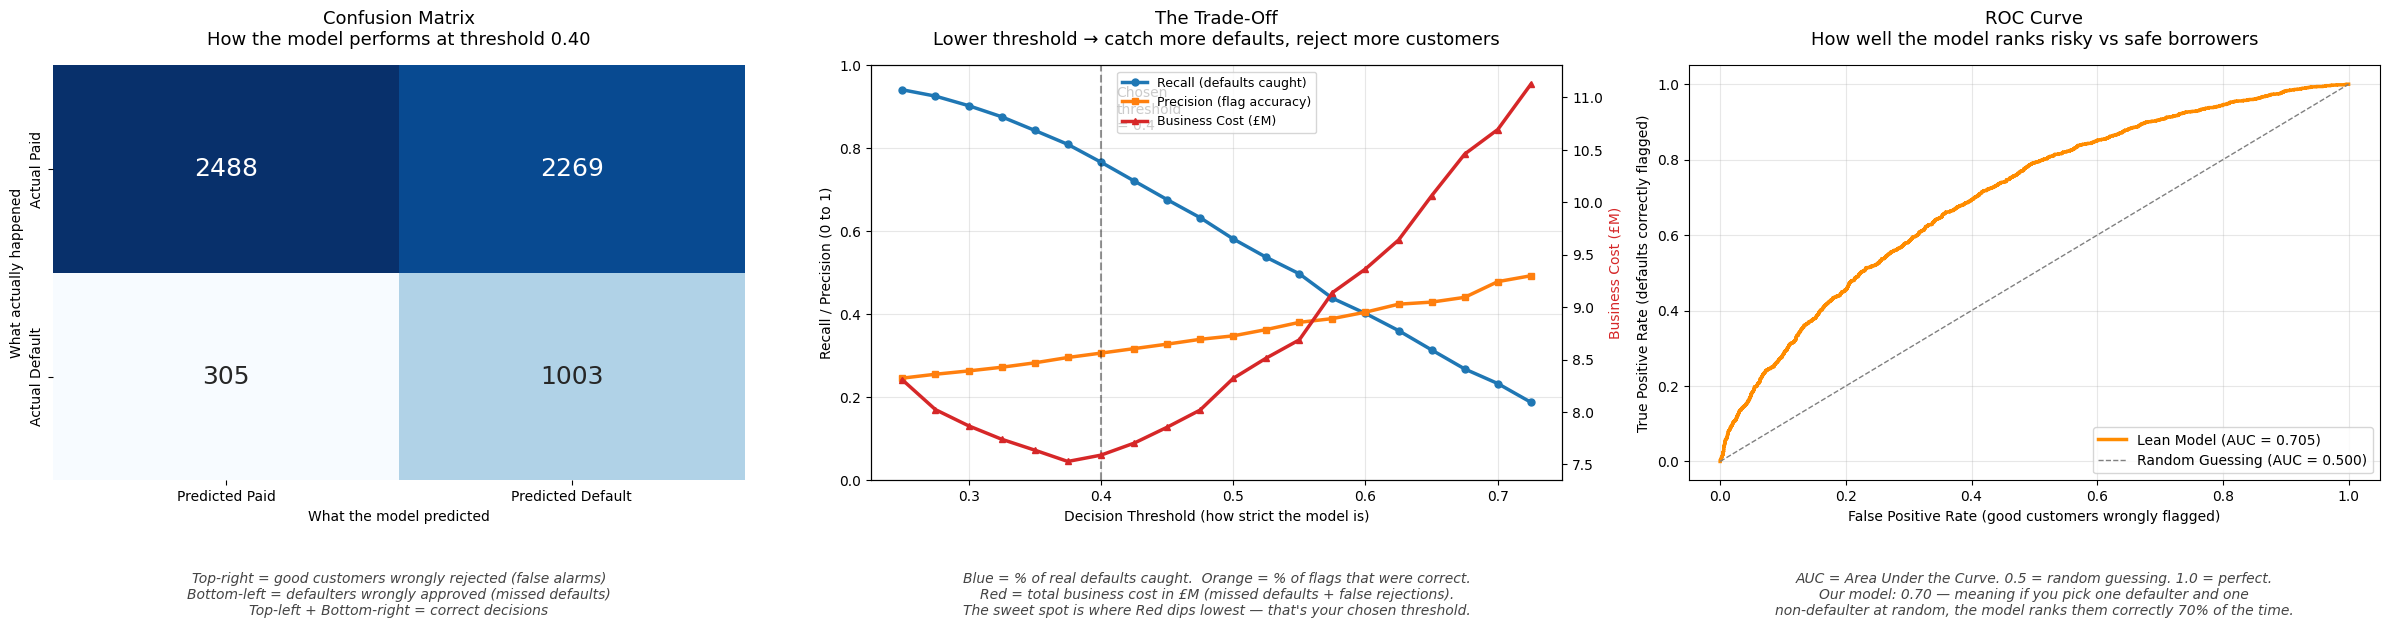


✅ Saved as 'credit_risk_final_visualisation.png'


In [53]:
# STEP 16 (FINAL): Production visualisation with built-in captions
from sklearn.metrics import roc_curve, precision_recall_curve

final_threshold = 0.40
y_pred_final = (y_pred_proba_lean >= final_threshold).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lean)
auc_final = roc_auc_score(y_test, y_pred_proba_lean)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# ============ CHART 1: Confusion Matrix ============
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Paid', 'Predicted Default'],
            yticklabels=['Actual Paid', 'Actual Default'],
            ax=axes[0], cbar=False, annot_kws={'size': 18})
axes[0].set_title('Confusion Matrix\nHow the model performs at threshold 0.40', fontsize=13, pad=15)
axes[0].set_xlabel('What the model predicted')
axes[0].set_ylabel('What actually happened')

# Caption underneath
axes[0].text(0.5, -0.22,
             "Top-right = good customers wrongly rejected (false alarms)\n"
             "Bottom-left = defaulters wrongly approved (missed defaults)\n"
             "Top-left + Bottom-right = correct decisions",
             ha='center', va='top', fontsize=10, transform=axes[0].transAxes,
             style='italic', color='#444444')


# ============ CHART 2: Threshold Trade-Off (THE BOARD CHART) ============
thresholds_plot = np.arange(0.25, 0.75, 0.025)
precisions, recalls, costs = [], [], []

for t in thresholds_plot:
    y_pred_t = (y_pred_proba_lean >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t))
    costs.append(((fn * 10000) + (fp * 2000)) / 1_000_000)

ax2 = axes[1]
ax2_twin = ax2.twinx()

l1, = ax2.plot(thresholds_plot, recalls, color='#1f77b4', linewidth=2.5, marker='o', markersize=5, label='Recall (defaults caught)')
l2, = ax2.plot(thresholds_plot, precisions, color='#ff7f0e', linewidth=2.5, marker='s', markersize=5, label='Precision (flag accuracy)')
l3, = ax2_twin.plot(thresholds_plot, costs, color='#d62728', linewidth=2.5, marker='^', markersize=5, label='Business Cost (£M)')

ax2.axvline(final_threshold, color='black', linestyle='--', alpha=0.4)
ax2.text(final_threshold + 0.012, 0.95, f'Chosen\nthreshold\n= {final_threshold}',
         fontsize=10, va='top', color='black')

ax2.set_xlabel('Decision Threshold (how strict the model is)')
ax2.set_ylabel('Recall / Precision (0 to 1)', color='black')
ax2_twin.set_ylabel('Business Cost (£M)', color='#d62728')
ax2.set_title('The Trade-Off\nLower threshold → catch more defaults, reject more customers', fontsize=13, pad=15)
ax2.legend(handles=[l1, l2, l3], loc='upper center', fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_ylim(0, 1)

# Caption underneath
axes[1].text(0.5, -0.22,
             "Blue = % of real defaults caught.  Orange = % of flags that were correct.\n"
             "Red = total business cost in £M (missed defaults + false rejections).\n"
             "The sweet spot is where Red dips lowest — that's your chosen threshold.",
             ha='center', va='top', fontsize=10, transform=axes[1].transAxes,
             style='italic', color='#444444')


# ============ CHART 3: ROC Curve ============
axes[2].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'Lean Model (AUC = {auc_final:.3f})')
axes[2].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--',
             label='Random Guessing (AUC = 0.500)')
axes[2].set_xlabel('False Positive Rate (good customers wrongly flagged)')
axes[2].set_ylabel('True Positive Rate (defaults correctly flagged)')
axes[2].set_title('ROC Curve\nHow well the model ranks risky vs safe borrowers', fontsize=13, pad=15)
axes[2].legend(loc='lower right')
axes[2].grid(alpha=0.3)

# Caption underneath
axes[2].text(0.5, -0.22,
             "AUC = Area Under the Curve. 0.5 = random guessing. 1.0 = perfect.\n"
             "Our model: 0.70 — meaning if you pick one defaulter and one\n"
             "non-defaulter at random, the model ranks them correctly 70% of the time.",
             ha='center', va='top', fontsize=10, transform=axes[2].transAxes,
             style='italic', color='#444444')


plt.subplots_adjust(bottom=0.25)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('credit_risk_final_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Saved as 'credit_risk_final_visualisation.png'")